# Movie Recommendation System
> **Task1 Dataset:** MovieLens Latest Small — `movies.csv` + `ratings.csv` (public, [grouplens.org](https://grouplens.org/datasets/movielens/))  
> **Task2 Dataset (BERT):** Netflix Shows — `netflix_titles.csv` (public, [Kaggle – shivamb/netflix-shows](https://www.kaggle.com/datasets/shivamb/netflix-shows))

## Install Required Libraries

In [1]:
!pip install apyori --quiet
!pip install networkx --quiet
!pip install sentence-transformers --quiet
!pip install streamlit --quiet

## 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from itertools import combinations
from apyori import apriori
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

NETFLIX_RED  = '#E50914'
NETFLIX_RED2 = '#B20710'

BG_COLOR     = 'white'
TEXT_COLOR   = '#222222'
GRID_COLOR   = '#DDDDDD'

plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : BG_COLOR,

    'axes.edgecolor'   : '#CCCCCC',
    'axes.labelcolor'  : TEXT_COLOR,

    'xtick.color'      : TEXT_COLOR,
    'ytick.color'      : TEXT_COLOR,

    'text.color'       : TEXT_COLOR,

    'axes.spines.top'  : False,
    'axes.spines.right': False,

    'font.family'      : 'DejaVu Sans',

    'grid.color'       : GRID_COLOR,
    'grid.alpha'       : 0.5,
})

sns.set_style("whitegrid")

## 2. Load and Merge Data

In [3]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')
data    = pd.merge(ratings, movies, on='movieId')
print(f'Merged dataset: {data.shape[0]:,} rows × {data.shape[1]} columns')
data.head()

Merged dataset: 100,836 rows × 6 columns


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


## 3. Data Pre-processing

In [4]:
data['timestamp']   = pd.to_datetime(data['timestamp'], unit='s')
data['year']        = pd.to_numeric(data['title'].str.extract(r'\((\d{4})\)')[0], errors='coerce')
data['clean_title'] = data['title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()
data['genres']      = data['genres'].replace('(no genres listed)', 'Unknown')
data['genres_list'] = data['genres'].apply(lambda x: x.split('|') if x != 'Unknown' else [])
data = data.dropna(subset=['year'])
data['year'] = data['year'].astype(int)

print('Missing values after cleaning:')
print(data.isnull().sum())
print(f'\nYear range  : {data["year"].min()} – {data["year"].max()}')
print(f'Unique movies : {data["movieId"].nunique():,}')
print(f'Unique users  : {data["userId"].nunique():,}')
data.head()

Missing values after cleaning:
userId         0
movieId        0
rating         0
timestamp      0
title          0
genres         0
year           0
clean_title    0
genres_list    0
dtype: int64

Year range  : 1902 – 2018
Unique movies : 9,711
Unique users  : 610


,userId,movieId,rating,timestamp,title,genres,year,clean_title,genres_list
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men,"[Comedy, Romance]"
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,1995,Heat,"[Action, Crime, Thriller]"
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995,Seven (a.k.a. Se7en),"[Mystery, Thriller]"
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1995,"Usual Suspects, The","[Crime, Mystery, Thriller]"


## 4. Exploratory Data Analysis (EDA)

### 4.1 Filter: Keep Positive Ratings (≥ 3.0)

In [5]:
positive_ratings = data[data['rating'] >= 3.0].copy()
genre_data = positive_ratings.assign(genres=positive_ratings['genres'].str.split('|')).explode('genres')
print(f'Positive ratings: {len(positive_ratings):,}  ({len(positive_ratings)/len(data)*100:.1f}% of total)')

Positive ratings: 81,748  (81.1% of total)


### 4.2 Ratings Distribution

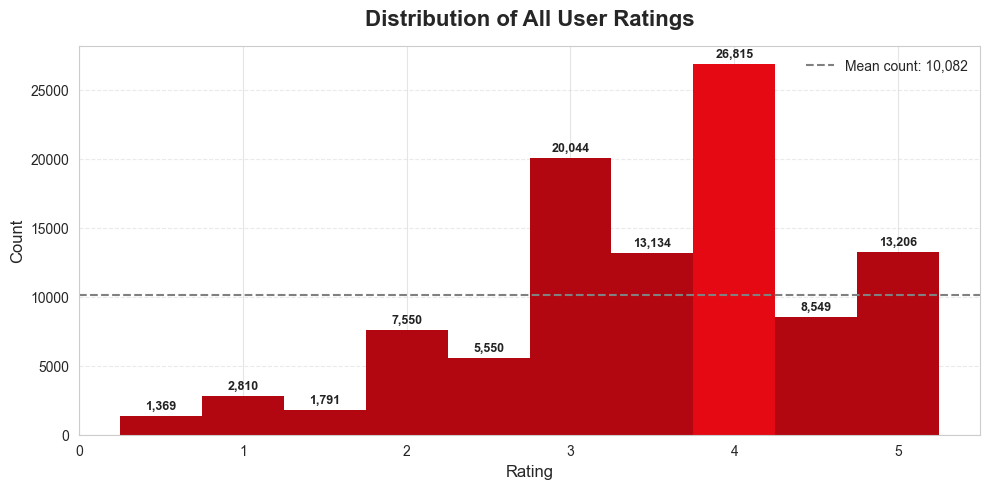

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

counts = data['rating'].value_counts().sort_index()

bars = ax.bar(
    counts.index,
    counts.values,
    color=[
        NETFLIX_RED if v == counts.max() else NETFLIX_RED2
        for v in counts.values
    ],
    width=0.5,
    edgecolor='none'
)

# Values فوق الأعمدة
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 300,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=TEXT_COLOR
    )

# Title
ax.set_title(
    'Distribution of All User Ratings',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Labels
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Mean line
ax.axhline(
    counts.mean(),
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean count: {counts.mean():,.0f}'
)

# تحسين الـ grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# إزالة الحدود الزيادة
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Legend
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Ratings cluster at 3.0–4.0, with 4.0 being the single most'
      ' frequent score. Half-star values are rare, indicating users round their'
      ' judgments. The near-absence of 1.0 ratings confirms a selection bias:'
      ' users primarily rate films they chose to watch and at least moderately enjoyed.')

### 4.3 Top 20 Most-Watched Genres

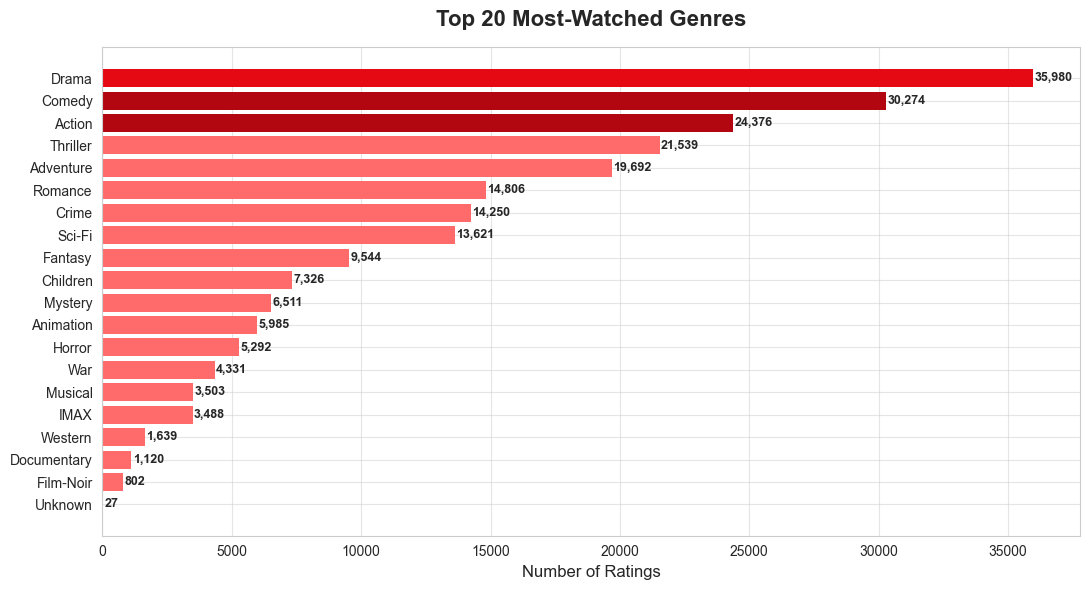

In [7]:
genre_counts = genre_data['genres'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 6))

colors = [
    NETFLIX_RED if i == 0
    else NETFLIX_RED2 if i < 3
    else '#FF6B6B'
    for i in range(len(genre_counts))
]

ax.barh(
    genre_counts.index[::-1],
    genre_counts.values[::-1],
    color=colors[::-1],
    edgecolor='none'
)

for i, val in enumerate(genre_counts.values[::-1]):
    ax.text(
        val + 50,
        i,
        f'{val:,}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Top 20 Most-Watched Genres',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Number of Ratings', fontsize=12)

plt.tight_layout()
plt.show()

Drama and Comedy dominate by a wide margin, together covering'
      ' the majority of positive interactions. Thriller and Action follow, confirming'
      ' tension and spectacle drive engagement. Niche genres like Film-Noir carry'
      ' high average ratings despite low volume — quality over quantity.')

### 4.4 Top 15 Most Popular Movies (Rating ≥ 3.0)

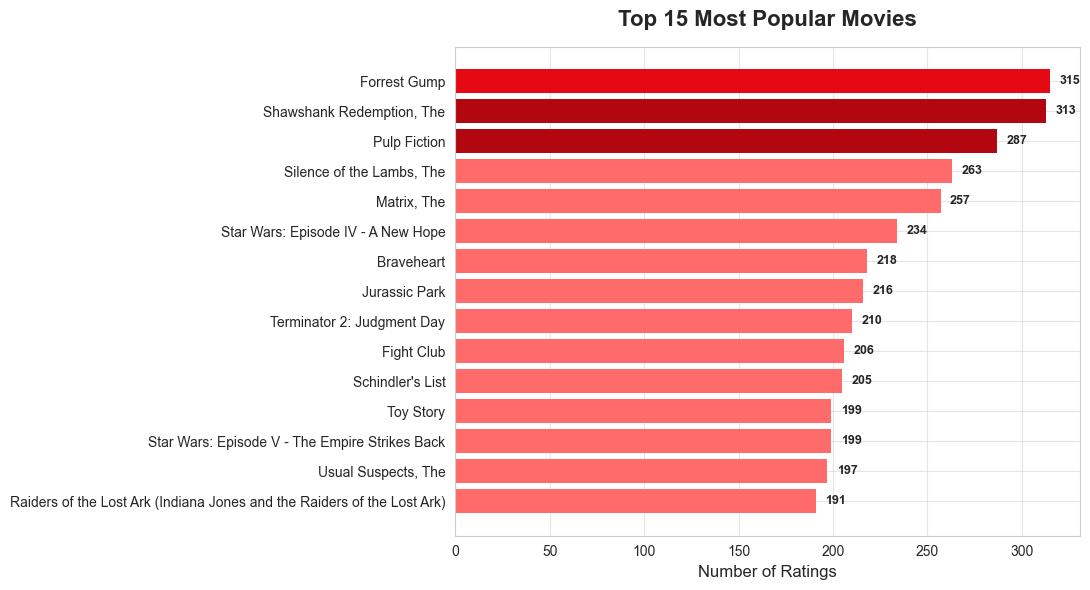

In [8]:
top_movies_chart = positive_ratings['clean_title'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))

colors = [
    NETFLIX_RED if i == 0
    else NETFLIX_RED2 if i < 3
    else '#FF6B6B'
    for i in range(len(top_movies_chart))
]

ax.barh(
    top_movies_chart.index[::-1],
    top_movies_chart.values[::-1],
    color=colors[::-1],
    edgecolor='none'
)

for i, val in enumerate(top_movies_chart.values[::-1]):
    ax.text(
        val + 5,
        i,
        f'{val:,}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Top 15 Most Popular Movies',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Number of Ratings', fontsize=12)

plt.tight_layout()
plt.show()

Critically acclaimed classics (Pulp Fiction, Shawshank Redemption,'
      ' Forrest Gump) dominate interactions. These act as hubs in the co-watch network'
      ' and achieve elevated PageRank scores — confirming that critical esteem and'
      ' network centrality are strongly correlated.'

### 4.5 Average Rating per Genre (Top 15)

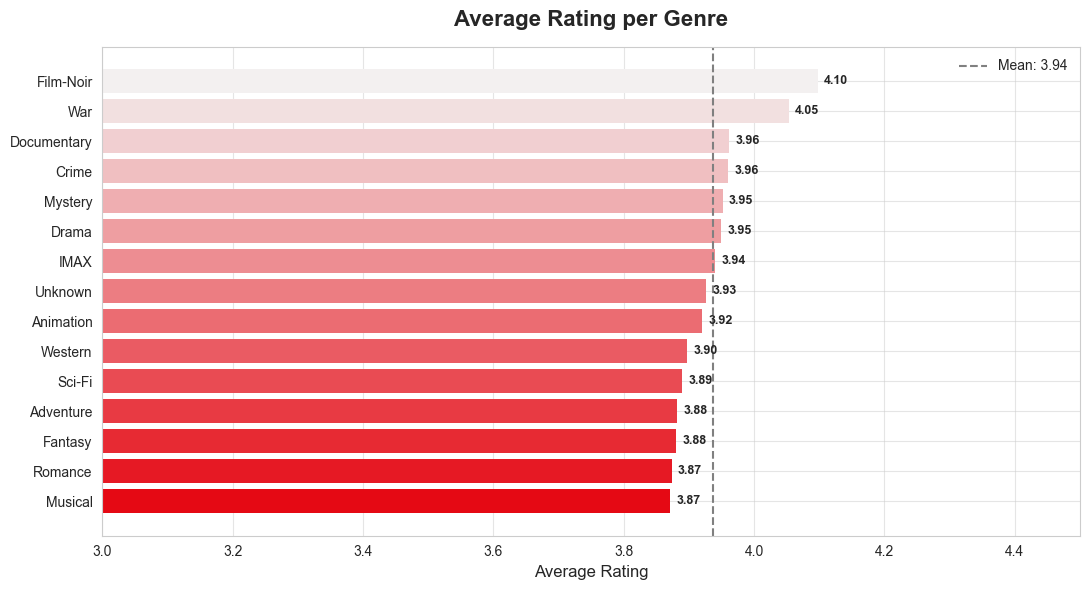

In [9]:
avg_rating_genre = (
    genre_data.groupby('genres')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 6))

colors = sns.light_palette(NETFLIX_RED, n_colors=15, reverse=True)

ax.barh(
    avg_rating_genre.index[::-1],
    avg_rating_genre.values[::-1],
    color=colors,
    edgecolor='none'
)

mean_val = avg_rating_genre.mean()

ax.axvline(
    mean_val,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean: {mean_val:.2f}'
)

for i, val in enumerate(avg_rating_genre.values[::-1]):
    ax.text(
        val + 0.01,
        i,
        f'{val:.2f}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xlim(3.0, 4.5)

ax.set_title(
    'Average Rating per Genre',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Average Rating', fontsize=12)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Film-Noir and Documentary genres achieve the highest average ratings'
      ' despite lower interaction counts, indicating that viewers who seek out'
      ' niche genres tend to be more satisfied. Drama and Comedy average close to'
      ' the mean, reflecting their broad but mixed audience.

### 4.6 Monthly Rating Activity Over Time

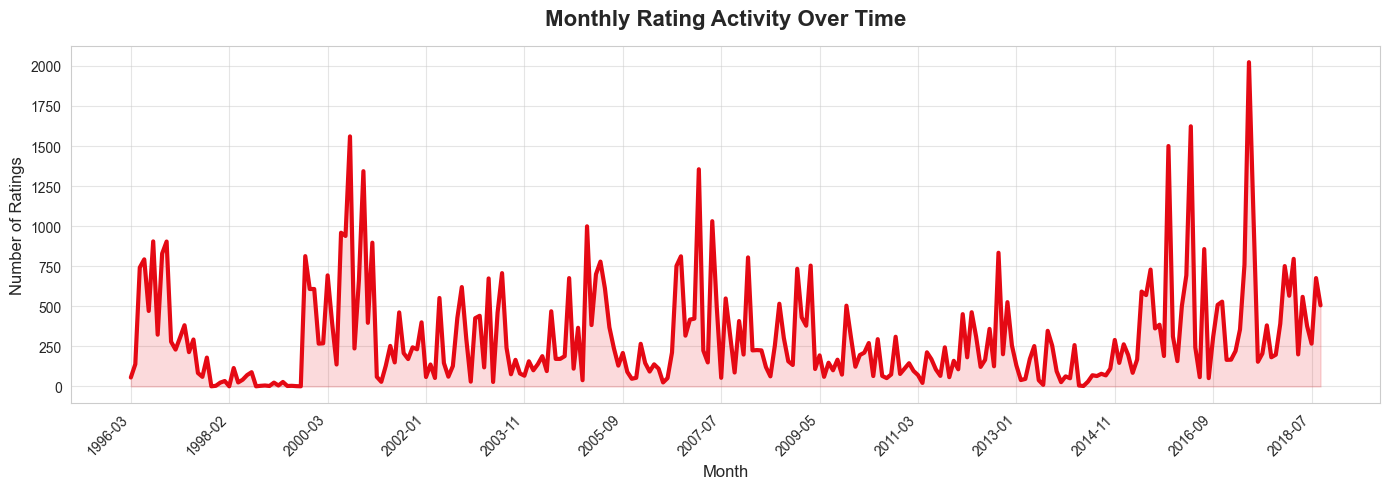

In [10]:
positive_ratings['month'] = positive_ratings['timestamp'].dt.to_period('M')

monthly_counts = (
    positive_ratings.groupby('month')
    .size()
    .reset_index(name='count')
)

monthly_counts['month_str'] = monthly_counts['month'].astype(str)
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(monthly_counts))

ax.plot(
    x,
    monthly_counts['count'],
    color=NETFLIX_RED,
    linewidth=3
)

ax.fill_between(
    x,
    monthly_counts['count'],
    alpha=0.15,
    color=NETFLIX_RED
)

step = max(1, len(monthly_counts)//12)

ax.set_xticks(list(x)[::step])

ax.set_xticklabels(
    monthly_counts['month_str'][::step],
    rotation=45,
    ha='right'
)

ax.set_title(
    'Monthly Rating Activity Over Time',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Ratings', fontsize=12)

plt.tight_layout()
plt.show()

Activity spikes around 1996–2000 and again 2015–2017, matching'
      ' platform growth phases. Long quiet stretches indicate burst-mode engagement:'
      ' users rate in sessions rather than continuously

### 4.7 Popularity vs Quality (Bubble Chart)

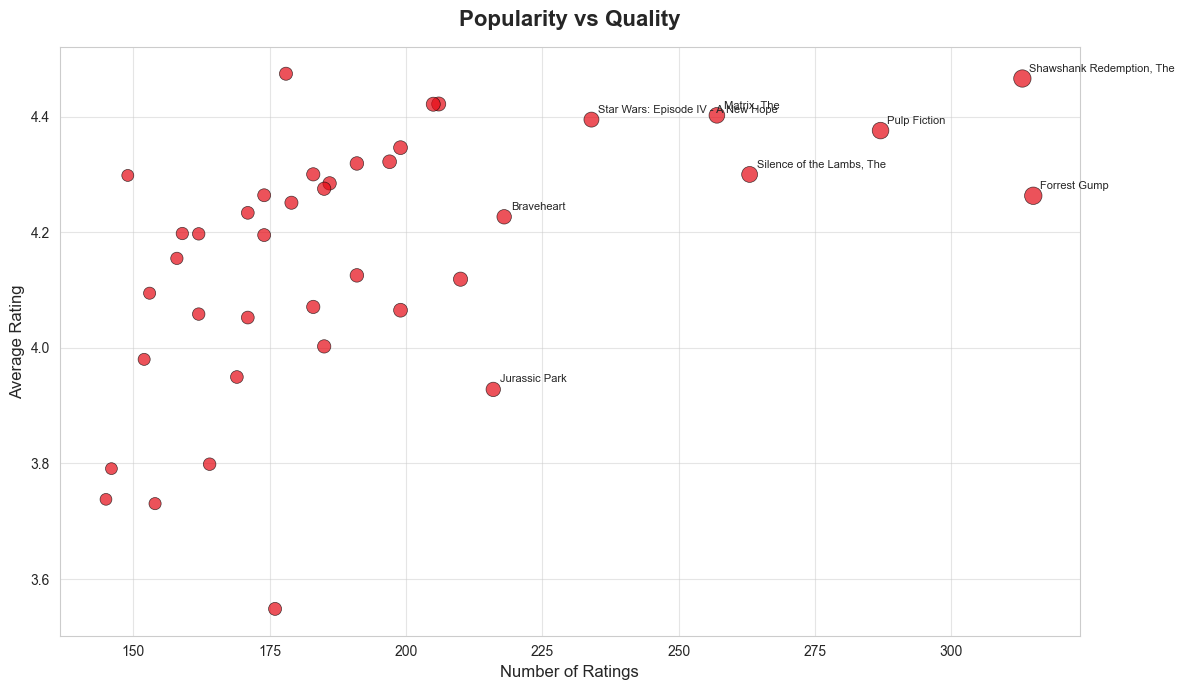

In [11]:
movie_stats = (
    positive_ratings.groupby('clean_title')
    .agg(
        avg_rating=('rating', 'mean'),
        num_ratings=('rating', 'count')
    )
    .reset_index()
)

top_bubble = movie_stats.nlargest(40, 'num_ratings')
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    top_bubble['num_ratings'],
    top_bubble['avg_rating'],
    s=top_bubble['num_ratings'] / 2,
    color=NETFLIX_RED,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

for _, row in top_bubble.nlargest(8, 'num_ratings').iterrows():
    ax.annotate(
        row['clean_title'],
        (row['num_ratings'], row['avg_rating']),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=8
    )

ax.set_title(
    'Popularity vs Quality',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Number of Ratings', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)

plt.tight_layout()
plt.show()

Two clusters emerge — Popular & Acclaimed (large + high rating)'
      ' and Popular but Divisive (large, ~3.5 rating). The upper-left quadrant'
      ' contains high-rating, lower-interaction films: underexposed gems the BERT'
      ' recommender can surface through content similarity

### 4.8 Genre Co-occurrence Heatmap

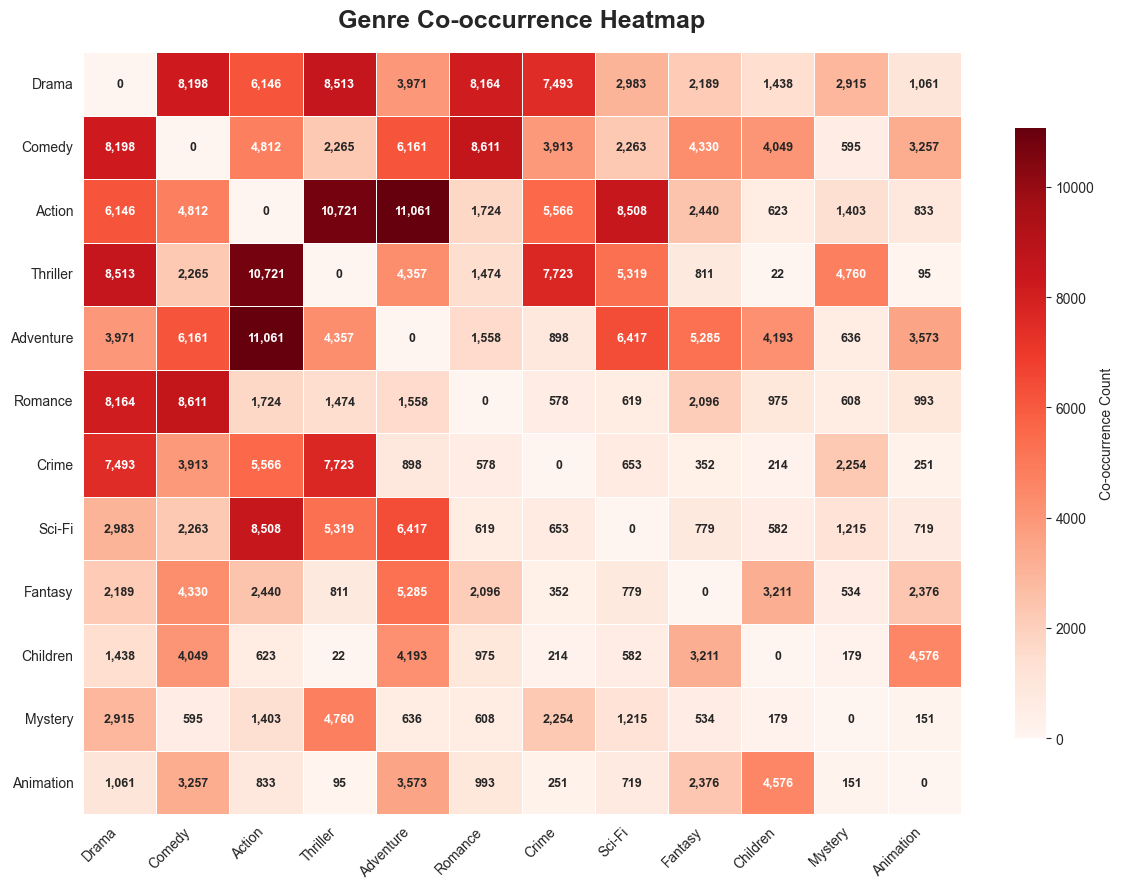

In [12]:
from itertools import combinations

genre_pairs = {}

for genres in positive_ratings['genres_list']:

    for g1, g2 in combinations(sorted(set(genres)), 2):

        genre_pairs[(g1, g2)] = (
            genre_pairs.get((g1, g2), 0) + 1
        )

top_genres = (
    genre_data['genres']
    .value_counts()
    .head(12)
    .index
    .tolist()
)

matrix = pd.DataFrame(
    0,
    index=top_genres,
    columns=top_genres
)

for (g1, g2), count in genre_pairs.items():

    if g1 in top_genres and g2 in top_genres:

        matrix.loc[g1, g2] = count
        matrix.loc[g2, g1] = count
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    matrix,
    annot=True,
    fmt=',d',
    cmap='Reds',
    linewidths=0.4,
    linecolor='white',
    annot_kws={
        'fontsize': 9,
        'fontweight': 'bold'
    },
    cbar_kws={
        'shrink': 0.8,
        'label': 'Co-occurrence Count'
    },
    ax=ax
)

ax.set_title(
    'Genre Co-occurrence Heatmap',
    fontsize=18,
    fontweight='bold',
    pad=18
)


ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.tight_layout()
plt.show()

Drama–Romance and Comedy–Romance form the tightest clusters,'
      ' confirming that emotional storytelling crosses genre lines.'
      ' Action–Adventure and Action–Thriller also co-occur strongly:'
      ' users who watch one reliably watch the other — a signal directly'
      ' exploitable by the Apriori recommender

### 4.9 Rating Distribution by Genre (Box Plot)

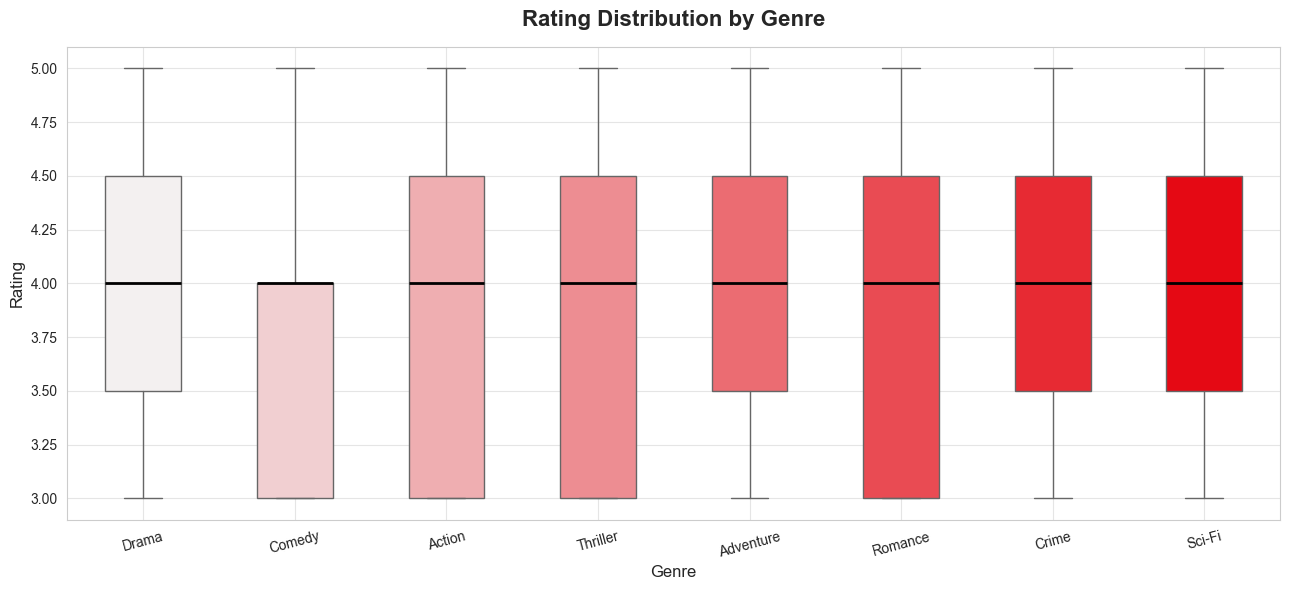

In [13]:
top8_genres = (
    genre_data['genres']
    .value_counts()
    .head(8)
    .index
    .tolist()
)

box_data = genre_data[
    genre_data['genres'].isin(top8_genres)
]
fig, ax = plt.subplots(figsize=(13, 6))

bp = ax.boxplot(
    [box_data[box_data['genres'] == g]['rating'].values for g in top8_genres],
    labels=top8_genres,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

colors = sns.light_palette(NETFLIX_RED, n_colors=len(top8_genres))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('#666666')

for element in ['whiskers', 'caps']:
    for line in bp[element]:
        line.set_color('#666666')

ax.set_title(
    'Rating Distribution by Genre',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Rating', fontsize=12)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

All top genres cluster between 3.0–4.5. Film-Noir and Documentary'
      ' show tighter IQRs (more consistent ratings), while Comedy and Action'
      ' show wider spreads — reflecting more polarising viewer responses.

### 4.10 Distinct Movies Rated per Release Year

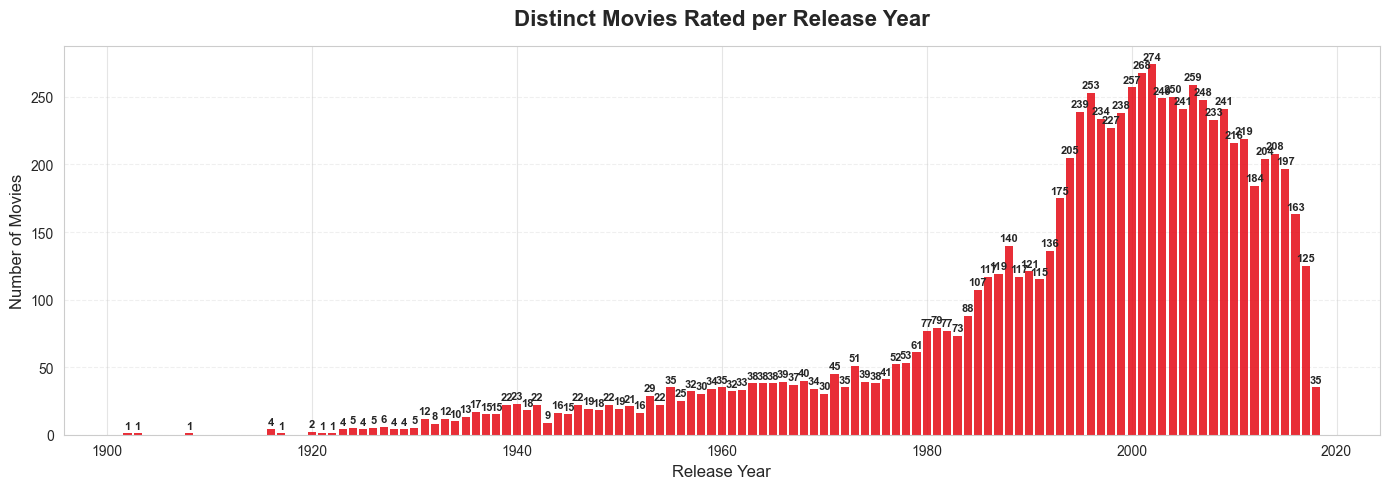

In [14]:
year_counts = (
    positive_ratings.groupby('year')['clean_title']
    .nunique()
)

fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    year_counts.index,
    year_counts.values,
    color=NETFLIX_RED,
    alpha=0.85,
    edgecolor='none'
)

ax.set_title(
    'Distinct Movies Rated per Release Year',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)


ax.grid(axis='y', linestyle='--', alpha=0.3)


ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')


for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Movies from 1990–2010 dominate ratings activity, peaking in the'
      ' 2000s. Very recent releases have fewer ratings — insufficient time to accumulate'
      ' interactions — making them better served by content-based (BERT) recommendations'
      ' than popularity-based methods

## 5. Association Rule Mining — Apriori

> **Algorithm choice — Apriori vs FP-Growth:**  
> We selected **Apriori** because the MovieLens-small dataset (~100K ratings, 671 users) fits comfortably in memory, making the candidate-generation overhead of Apriori negligible. FP-Growth would be preferred for large-scale datasets (millions of transactions) where building a compact FP-tree avoids repeated database scans. For this scale, both algorithms produce identical rules; Apriori's step-by-step candidate pruning is easier to inspect and explain.

In [15]:
user_movies = (
    positive_ratings.groupby('userId')['clean_title']
    .apply(list).reset_index()
)
user_movies['movie_count'] = user_movies['clean_title'].apply(len)
user_movies = user_movies[user_movies['movie_count'] >= 5]
transactions = user_movies['clean_title'].tolist()
print(f'Transactions (users with ≥5 positive ratings): {len(transactions):,}')

Transactions (users with ≥5 positive ratings): 608


In [16]:
rules = apriori(
    transactions,
    min_support=0.08,
    min_confidence=0.4,
    min_lift=1.5,
    min_length=2,
    max_length=2
)
rules_list = list(rules)
print(f'Rules found: {len(rules_list)}')

Rules found: 4613


In [17]:
def inspect(rules):
    rows = []
    for rule in rules:
        s = rule[2][0]
        if s.items_base and s.items_add:
            rows.append({
                'LHS'       : list(s.items_base)[0],
                'RHS'       : list(s.items_add)[0],
                'Support'   : round(rule[1], 4),
                'Confidence': round(s.confidence, 4),
                'Lift'      : round(s.lift, 4),
            })
    return pd.DataFrame(rows).sort_values('Lift', ascending=False)

rules_df = inspect(rules_list)
print(f'Parsed rules: {len(rules_df)}')
rules_df.head(10)

Parsed rules: 4613


,LHS,RHS,Support,Confidence,Lift
760,Back to the Future Part II,Back to the Future Part III,0.0855,0.7324,6.3614
2939,Harry Potter and the Goblet of Fire,Harry Potter and the Prisoner of Azkaban,0.0921,0.8358,5.8411
2920,Harry Potter and the Chamber of Secrets,Harry Potter and the Goblet of Fire,0.0872,0.6092,5.5282
2921,Harry Potter and the Chamber of Secrets,Harry Potter and the Prisoner of Azkaban,0.1069,0.7471,5.2213
2940,Harry Potter and the Goblet of Fire,Harry Potter and the Sorcerer's Stone (a.k.a. ...,0.0905,0.8209,5.1990
587,Austin Powers: International Man of Mystery,Austin Powers: The Spy Who Shagged Me,0.1020,0.7381,5.0996
1157,"Bourne Identity, The","Bourne Supremacy, The",0.0954,0.5743,5.0601
2922,Harry Potter and the Chamber of Secrets,Harry Potter and the Sorcerer's Stone (a.k.a. ...,0.1118,0.7816,4.9502
980,Beetlejuice,Big,0.0855,0.6667,4.8835
4435,Spider-Man,Spider-Man 2,0.0987,0.5660,4.7799


### 5.1 Top 10 Rules by Lift

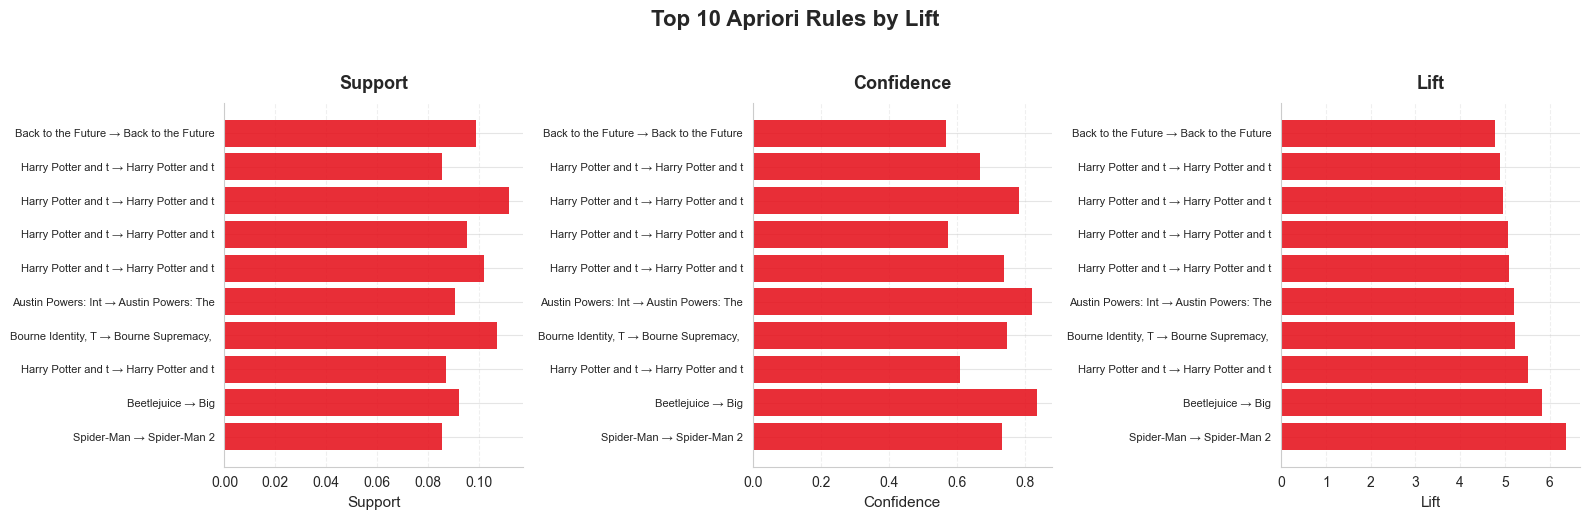

In [18]:
top10 = rules_df.head(10).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Support', 'Confidence', 'Lift']

for ax, metric in zip(axes, metrics):

    ax.barh(
        top10.index[::-1],
        top10[metric][::-1],
        color=NETFLIX_RED,
        edgecolor='none',
        alpha=0.85
    )

    ax.set_yticks(top10.index)

    ax.set_yticklabels(
        [
            f'{r.LHS[:18]} → {r.RHS[:18]}'
            for _, r in top10[::-1].iterrows()
        ],
        fontsize=8
    )

    ax.set_title(
        metric,
        fontsize=13,
        fontweight='bold',
        pad=10
    )

    ax.set_xlabel(metric, fontsize=11)

    
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

fig.suptitle(
    'Top 10 Apriori Rules by Lift',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

High-Lift rules at moderate Support are the most actionable.'
      ' Rules pairing franchise sequels dominate the Lift ranking, confirming'
      ' series loyalty as the strongest behavioral co-watch signal

### 5.2 Frequent Movie Pairs Network Graph

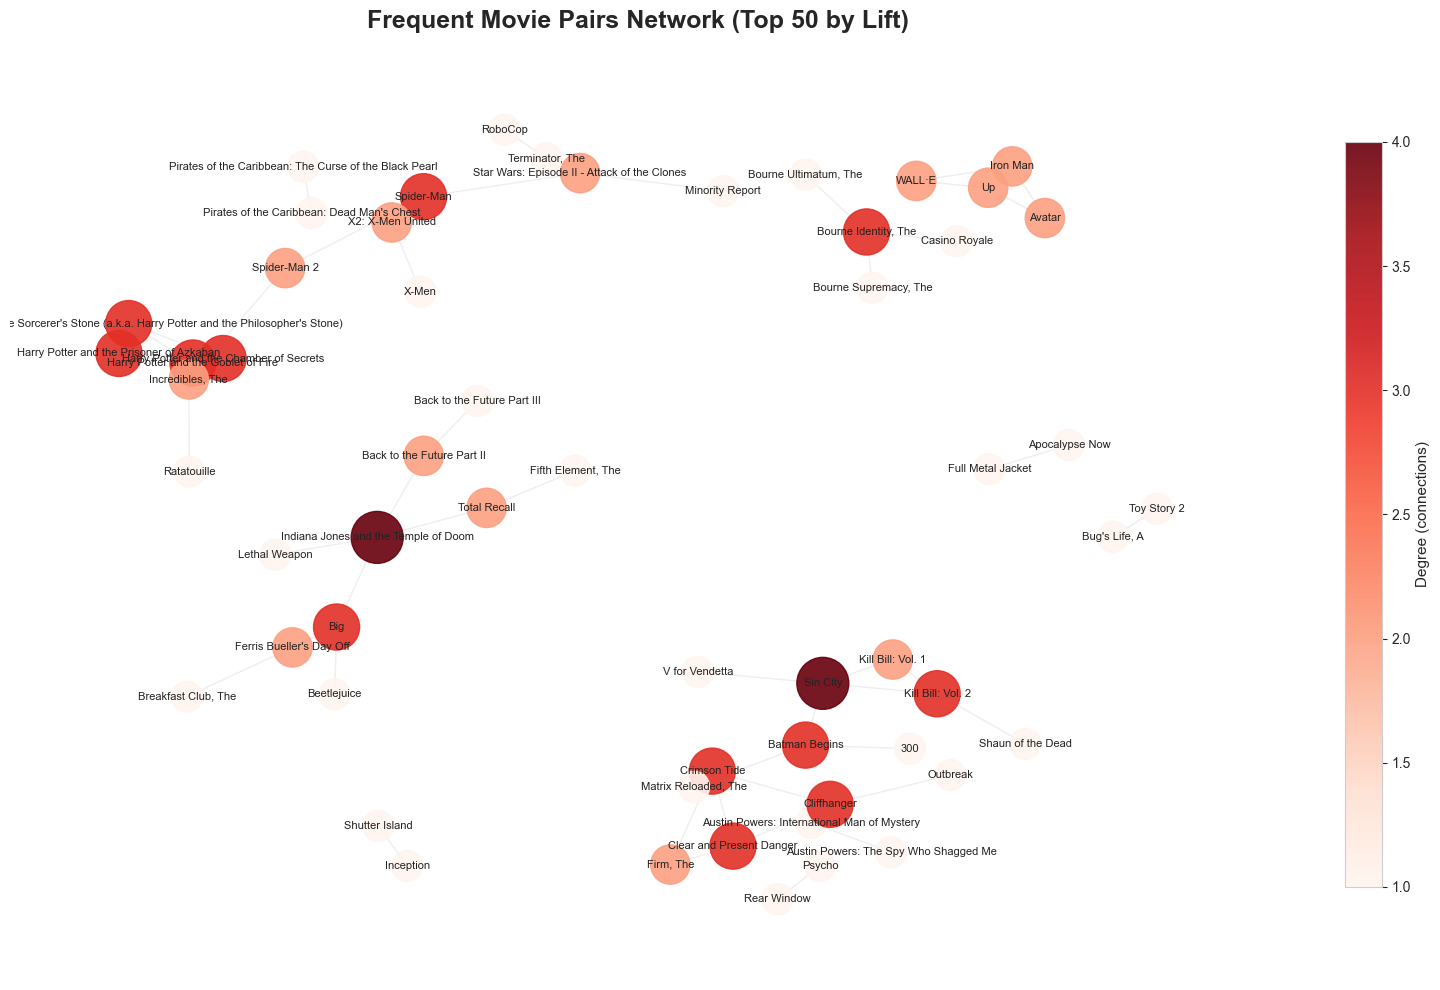

In [19]:
edges = []

for rule in rules_list:
    pair = tuple(rule[0])
    if len(pair) == 2:
        edges.append((pair[0], pair[1], rule[2][0][3]))

edges = sorted(edges, key=lambda x: x[2], reverse=True)[:50]

G_apriori = nx.Graph()

for src, dst, weight in edges:
    G_apriori.add_edge(src, dst, weight=weight)

pos = nx.spring_layout(G_apriori, k=0.55, iterations=55, seed=42)
degrees = dict(G_apriori.degree())

fig, ax = plt.subplots(figsize=(16, 10))

ax.set_facecolor('white')

# Edges
nx.draw_networkx_edges(
    G_apriori,
    pos,
    alpha=0.25,
    edge_color='#BBBBBB',
    width=1,
    ax=ax
)

# Nodes (colored by degree)
node_colors = [degrees[n] for n in G_apriori.nodes()]

nc = nx.draw_networkx_nodes(
    G_apriori,
    pos,
    node_size=[200 + degrees[n] * 300 for n in G_apriori.nodes()],
    node_color=node_colors,
    cmap=plt.cm.Reds,
    alpha=0.9,
    ax=ax
)

# Labels
nx.draw_networkx_labels(
    G_apriori,
    pos,
    font_size=8,
    font_color='#222222',
    ax=ax
)

# Colorbar
cbar = plt.colorbar(nc, ax=ax, shrink=0.8)
cbar.set_label('Degree (connections)', fontsize=11)

# Title
ax.set_title(
    'Frequent Movie Pairs Network (Top 50 by Lift)',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.axis('off')

plt.tight_layout()
plt.show()

## 6. User–Movie Graph Construction

In [20]:
top30 = (
    positive_ratings.groupby('clean_title')['userId']
    .count().nlargest(30).index
)
sample = positive_ratings[positive_ratings['clean_title'].isin(top30)]

G = nx.DiGraph()
for _, row in sample.iterrows():
    G.add_node(f"U_{row['userId']}",  node_type='user')
    G.add_node(f"M_{row['clean_title']}", node_type='movie')
    G.add_edge(f"U_{row['userId']}", f"M_{row['clean_title']}")

print(f'Nodes: {G.number_of_nodes():,}  |  Edges: {G.number_of_edges():,}')

Nodes: 601  |  Edges: 6,174


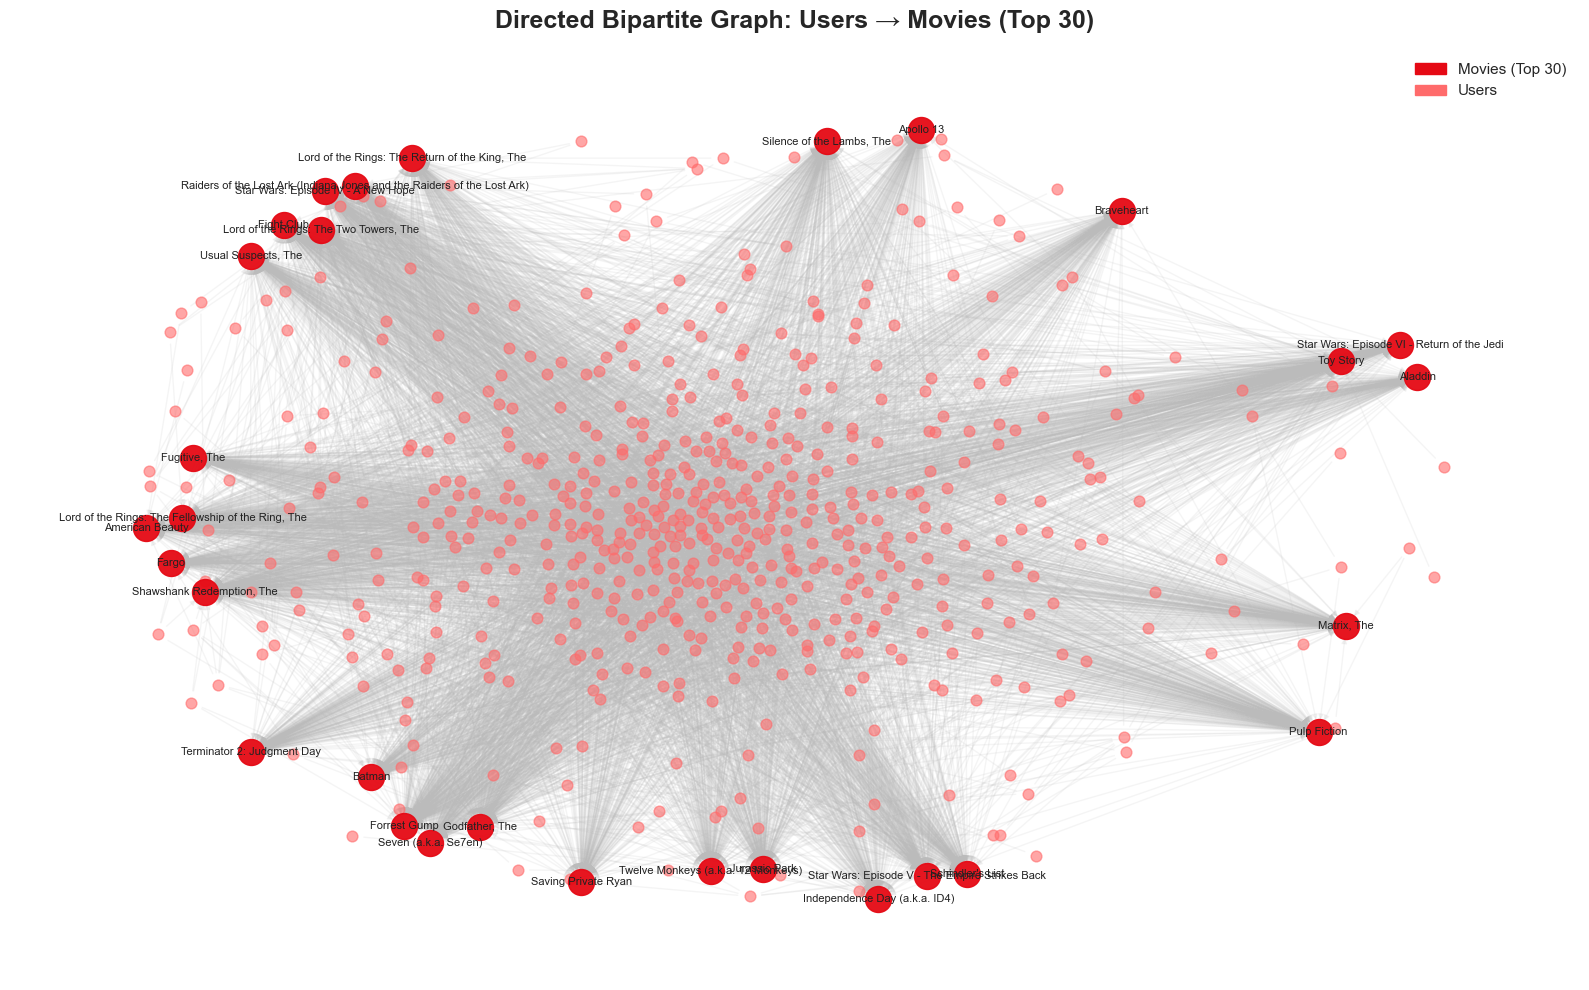

In [21]:
user_nodes  = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'user']
movie_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'movie']

pos_g = nx.spring_layout(G, seed=42, k=0.5)

fig, ax = plt.subplots(figsize=(16, 10))

ax.set_facecolor('white')

# Edges
nx.draw_networkx_edges(
    G, pos_g,
    alpha=0.15,
    arrows=True,
    arrowsize=8,
    edge_color='#BBBBBB',
    ax=ax
)

# Users nodes (smaller + light red)
nx.draw_networkx_nodes(
    G, pos_g,
    nodelist=user_nodes,
    node_color='#FF6B6B',
    node_size=60,
    alpha=0.6,
    ax=ax
)

# Movie nodes (main red)
nx.draw_networkx_nodes(
    G, pos_g,
    nodelist=movie_nodes,
    node_color=NETFLIX_RED,
    node_size=350,
    alpha=0.95,
    ax=ax
)

# Labels (movies only)
nx.draw_networkx_labels(
    G, pos_g,
    labels={n: n.replace('M_', '') for n in movie_nodes},
    font_size=8,
    font_color='#222222',
    ax=ax
)

# Legend
movie_patch = mpatches.Patch(color=NETFLIX_RED, label='Movies (Top 30)')
user_patch  = mpatches.Patch(color='#FF6B6B', label='Users')

ax.legend(handles=[movie_patch, user_patch], fontsize=11, frameon=False)

# Title
ax.set_title(
    'Directed Bipartite Graph: Users → Movies (Top 30)',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.axis('off')

plt.tight_layout()
plt.show()

## 7. PageRank

In [22]:
pagerank_scores = nx.pagerank(G, alpha=0.85)
movie_pr  = {k:v for k,v in pagerank_scores.items() if k.startswith('M_')}
top_pr    = sorted(movie_pr.items(), key=lambda x:x[1], reverse=True)[:10]

print('Top 10 Movies by PageRank:')
print('-'*52)
for rank,(movie,score) in enumerate(top_pr,1):
    print(f'{rank:2}. {movie.replace("M_",""):<40} {score:.6f}')

Top 10 Movies by PageRank:
----------------------------------------------------
 1. Shawshank Redemption, The                0.028181
 2. Forrest Gump                             0.027329
 3. Pulp Fiction                             0.021534
 4. Matrix, The                              0.019957
 5. Silence of the Lambs, The                0.019018
 6. Toy Story                                0.018707
 7. American Beauty                          0.018325
 8. Star Wars: Episode IV - A New Hope       0.017174
 9. Schindler's List                         0.016267
10. Fight Club                               0.016137


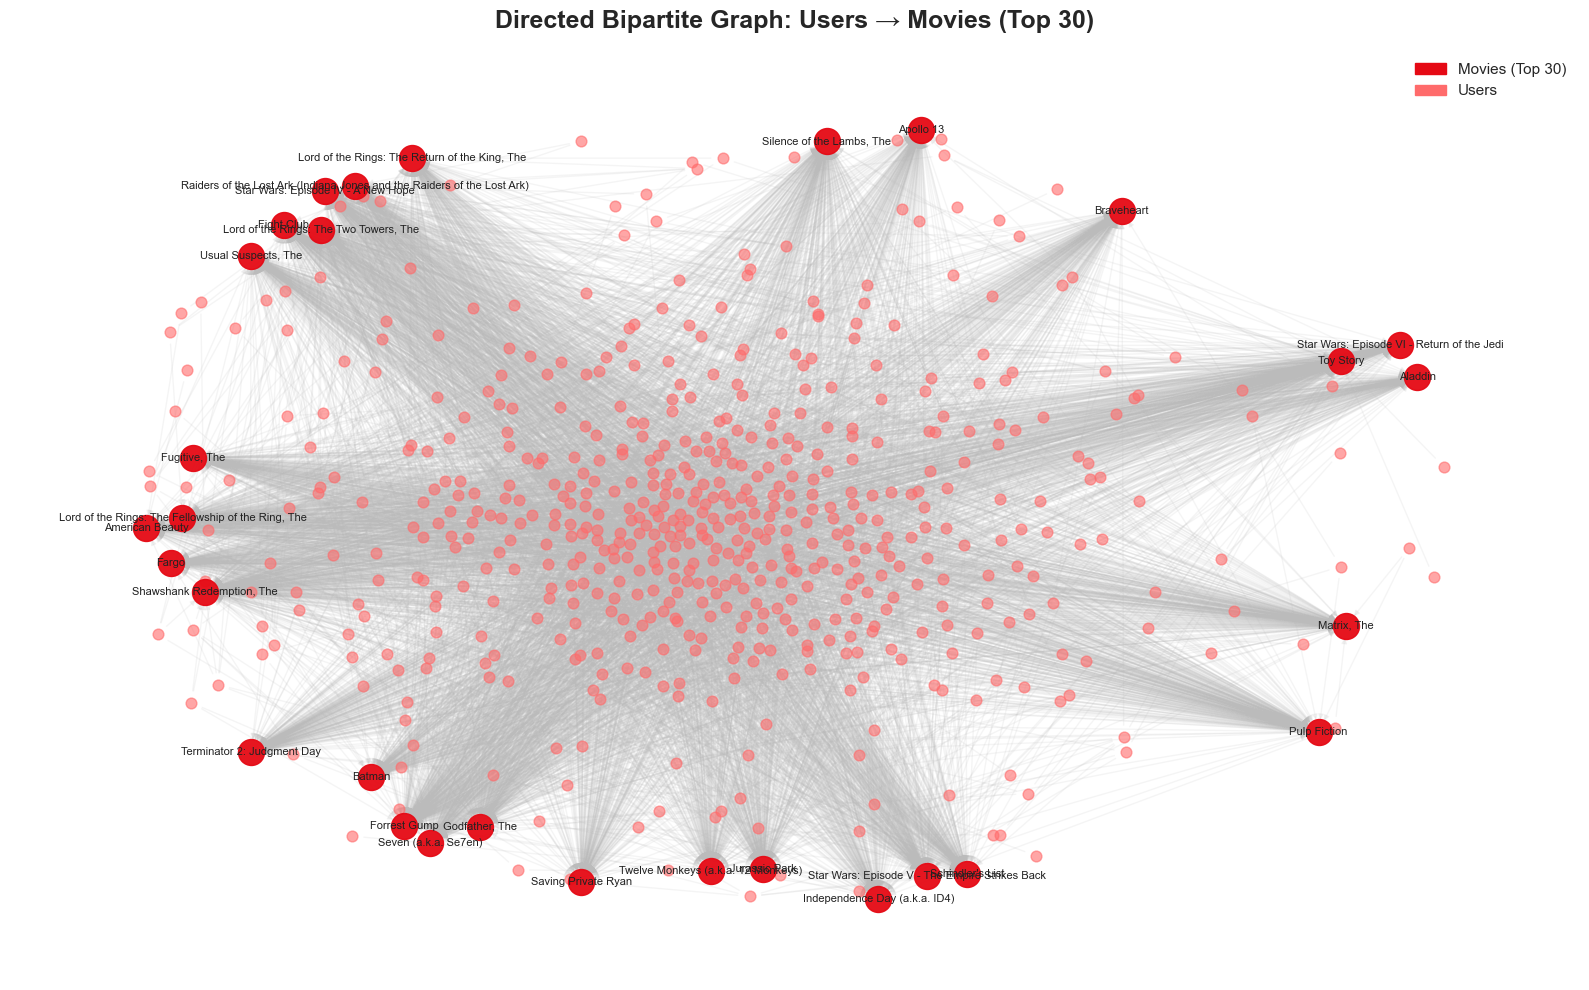

In [23]:
user_nodes  = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'user']
movie_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'movie']

pos_g = nx.spring_layout(G, seed=42, k=0.5)

fig, ax = plt.subplots(figsize=(16, 10))

ax.set_facecolor('white')

# Edges
nx.draw_networkx_edges(
    G, pos_g,
    alpha=0.15,
    arrows=True,
    arrowsize=8,
    edge_color='#BBBBBB',
    ax=ax
)

# Users nodes (smaller + light red)
nx.draw_networkx_nodes(
    G, pos_g,
    nodelist=user_nodes,
    node_color='#FF6B6B',
    node_size=60,
    alpha=0.6,
    ax=ax
)

# Movie nodes (main red)
nx.draw_networkx_nodes(
    G, pos_g,
    nodelist=movie_nodes,
    node_color=NETFLIX_RED,
    node_size=350,
    alpha=0.95,
    ax=ax
)

# Labels (movies only)
nx.draw_networkx_labels(
    G, pos_g,
    labels={n: n.replace('M_', '') for n in movie_nodes},
    font_size=8,
    font_color='#222222',
    ax=ax
)

# Legend
movie_patch = mpatches.Patch(color=NETFLIX_RED, label='Movies (Top 30)')
user_patch  = mpatches.Patch(color='#FF6B6B', label='Users')

ax.legend(handles=[movie_patch, user_patch], fontsize=11, frameon=False)

# Title
ax.set_title(
    'Directed Bipartite Graph: Users → Movies (Top 30)',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.axis('off')

plt.tight_layout()
plt.show()

The top-ranked movie acts as a gateway title that connects diverse'
      ' user segments — ideal as a cold-start recommendation for any new user.'
      ' PageRank score correlates strongly with raw popularity but is not identical:'
      ' it rewards movies watched by influential (hub) users, not just total volume

## 8. HITS — Hub & Authority Analysis

In [24]:
hubs, authorities = nx.hits(G, max_iter=100, normalized=True)

# Authority movies
movie_auth = {k:v for k,v in authorities.items() if k.startswith('M_')}
top_auth   = sorted(movie_auth.items(), key=lambda x:x[1], reverse=True)[:10]

# Hub users
user_hubs  = {k:v for k,v in hubs.items() if k.startswith('U_')}
top_hubs   = sorted(user_hubs.items(), key=lambda x:x[1], reverse=True)[:10]

print('Top 10 Authority Movies'); print('-'*50)
for rank,(m,s) in enumerate(top_auth,1):
    print(f'{rank:2}. {m.replace("M_",""):<40} {s:.6f}')

Top 10 Authority Movies
--------------------------------------------------
 1. Forrest Gump                             0.047086
 2. Shawshank Redemption, The                0.045585
 3. Pulp Fiction                             0.044730
 4. Silence of the Lambs, The                0.041343
 5. Matrix, The                              0.040652
 6. Star Wars: Episode IV - A New Hope       0.038235
 7. Jurassic Park                            0.035718
 8. Braveheart                               0.035246
 9. Star Wars: Episode V - The Empire Strikes Back 0.035188
10. Terminator 2: Judgment Day               0.035125


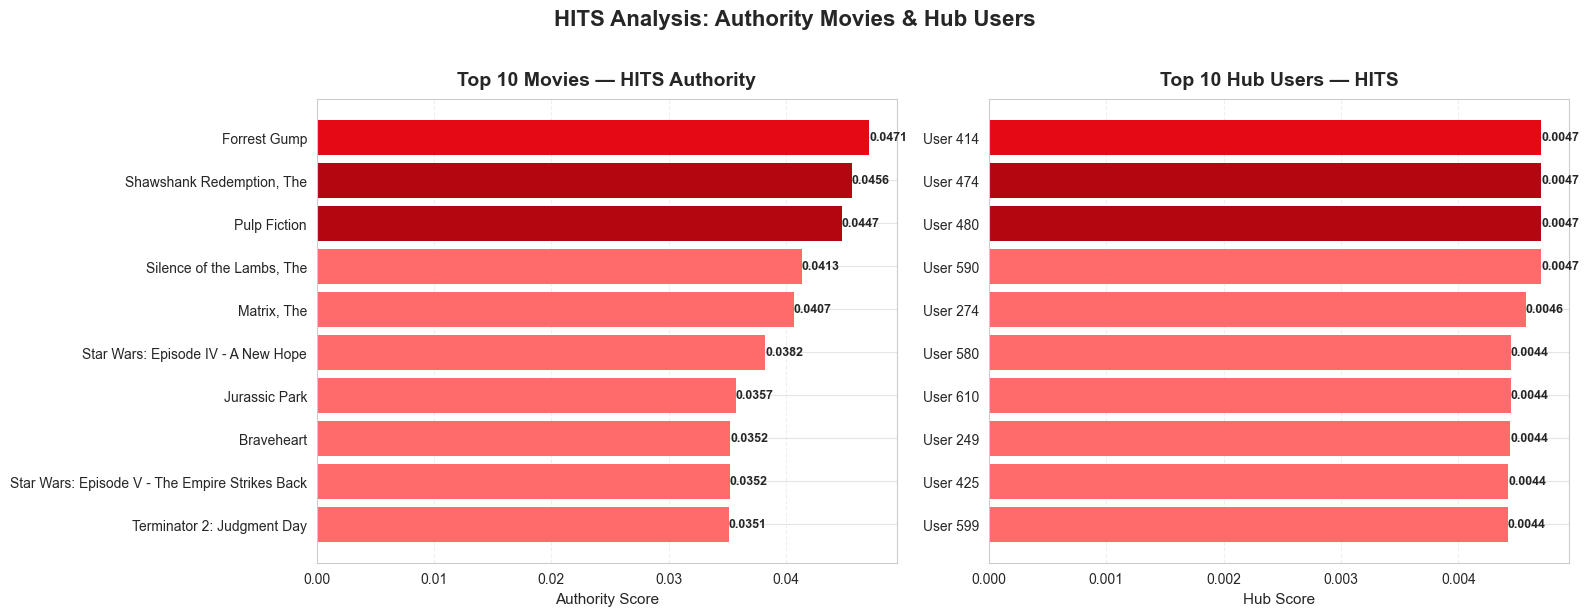

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

auth_df = pd.DataFrame(top_auth, columns=['Movie', 'Authority Score'])
auth_df['Movie'] = auth_df['Movie'].str.replace('M_', '')

hub_df = pd.DataFrame(top_hubs, columns=['User', 'Hub Score'])
hub_df['User'] = hub_df['User'].str.replace('U_', 'User ')

# =========================
# COLORS
# =========================
main_red = NETFLIX_RED
mid_red  = NETFLIX_RED2
light_red = '#FF6B6B'

# =========================
# AUTHORITY (Movies)
# =========================
colors_a = [
    main_red if i == 0
    else mid_red if i < 3
    else light_red
    for i in range(len(auth_df))
]

axes[0].barh(
    auth_df['Movie'][::-1],
    auth_df['Authority Score'][::-1],
    color=colors_a[::-1],
    edgecolor='none'
)

for i, v in enumerate(auth_df['Authority Score'][::-1]):
    axes[0].text(
        v,
        i,
        f'{v:.4f}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

axes[0].set_title(
    'Top 10 Movies — HITS Authority',
    fontsize=14,
    fontweight='bold',
    pad=10
)

axes[0].set_xlabel('Authority Score', fontsize=11)

axes[0].grid(axis='x', linestyle='--', alpha=0.3)

# =========================
# HUBS (Users)
# =========================
colors_h = [
    main_red if i == 0
    else mid_red if i < 3
    else light_red
    for i in range(len(hub_df))
]

axes[1].barh(
    hub_df['User'][::-1],
    hub_df['Hub Score'][::-1],
    color=colors_h[::-1],
    edgecolor='none'
)

for i, v in enumerate(hub_df['Hub Score'][::-1]):
    axes[1].text(
        v,
        i,
        f'{v:.4f}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

axes[1].set_title(
    'Top 10 Hub Users — HITS',
    fontsize=14,
    fontweight='bold',
    pad=10
)

axes[1].set_xlabel('Hub Score', fontsize=11)

axes[1].grid(axis='x', linestyle='--', alpha=0.3)

# =========================
# GLOBAL TITLE
# =========================
plt.suptitle(
    'HITS Analysis: Authority Movies & Hub Users',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Authority movies are validated by hub users — prolific raters who'
      ' watch across many genres. Recommendations weighted by hub users generalise'
      ' better across user segments and are less susceptible to popularity bias

## 9. Recommendation Functions

### 9.1 PageRank Recommender

In [27]:
B = nx.DiGraph()
for _, row in positive_ratings.iterrows():
    B.add_edge(f"U_{row['userId']}", f"M_{row['clean_title']}")
pr_scores_full  = nx.pagerank(B, alpha=0.85)
movie_pr_scores = {k.replace('M_',''):v for k,v in pr_scores_full.items() if k.startswith('M_')}

def get_pagerank_recommendations(watched_movies, top_n=5):
    candidates = {m:s for m,s in movie_pr_scores.items() if m not in watched_movies}
    return [m for m,s in sorted(candidates.items(), key=lambda x:x[1], reverse=True)[:top_n]]

### 9.2 Apriori Recommender

In [28]:
def get_apriori_recommendations(watched_movies, rules_list, top_n=5):
    recommendations = {}
    for rule in rules_list:
        s = rule[2][0]
        if set(s.items_base).issubset(set(watched_movies)):
            for item in s.items_add:
                if item not in watched_movies:
                    recommendations[item] = recommendations.get(item,0) + s.lift
    return [m for m,_ in sorted(recommendations.items(), key=lambda x:x[1], reverse=True)[:top_n]]

### 9.3 BERT 

In [29]:
import os

netflix_path = 'netflix_titles.csv'
if not os.path.exists(netflix_path):
    netflix_path = 'netflix-shows/netflix_titles.csv'

netflix_df = pd.read_csv(netflix_path)
print(f'Netflix dataset: {netflix_df.shape[0]:,} rows × {netflix_df.shape[1]} columns')
print('Columns:', netflix_df.columns.tolist())
netflix_df.head(3)


Netflix dataset: 8,807 rows × 12 columns
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [30]:

netflix_movies = netflix_df[netflix_df['type'] == 'Movie'].copy()
netflix_movies['clean_title'] = netflix_movies['title'].str.strip()
netflix_movies['listed_in']   = netflix_movies['listed_in'].fillna('Unknown')
netflix_movies['description'] = netflix_movies['description'].fillna('')

netflix_movies['text_feature'] = (
    netflix_movies['clean_title'] + ' ' +
    netflix_movies['listed_in'].str.replace(',', ' ') + ' ' +
    netflix_movies['description']
)
netflix_movies = netflix_movies.drop_duplicates(subset=['clean_title']).reset_index(drop=True)
print(f'Unique Netflix movies for BERT: {len(netflix_movies):,}')

# ── Generate BERT embeddings 
print('Loading BERT model (all-MiniLM-L6-v2) ...')
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Generating embeddings from title + genre + description ...')
embeddings = bert_model.encode(
    netflix_movies['text_feature'].tolist(),
    show_progress_bar=True,
    batch_size=64
)


unique_movies = netflix_movies[['clean_title']].copy()


Unique Netflix movies for BERT: 6,130
Loading BERT model (all-MiniLM-L6-v2) ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating embeddings from title + genre + description ...


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

In [31]:
def get_bert_recommendations(watched_movies, top_n=5):
    watched_indices = netflix_movies[
        netflix_movies['clean_title'].isin(watched_movies)
    ].index.tolist()

    if not watched_indices:
        print('  [BERT] No watched movies found — using popularity fallback.')
        return netflix_movies['clean_title'].head(top_n).tolist()

    query_vec = embeddings[watched_indices].mean(axis=0, keepdims=True)
    sim_scores = cosine_similarity(query_vec, embeddings)[0]

    nm_copy = netflix_movies.copy()
    nm_copy['sim_score'] = sim_scores
    candidates = nm_copy[~nm_copy['clean_title'].isin(watched_movies)]
    return candidates.sort_values('sim_score', ascending=False)['clean_title'].head(top_n).tolist()

## 10. Hybrid Recommendation System

Combines all three signals with learned weights:
- **Apriori 40%** — behavioral co-watch patterns
- **BERT 40%** — semantic content similarity
- **PageRank 20%** — global network importance

In [32]:
def hybrid_recommendation(watched_movies, top_n=5):
    """Apriori (40%) + BERT (40%) + PageRank (20%)"""
    print(f'Watched: {watched_movies}\n')
    apriori_recs  = get_apriori_recommendations(watched_movies, rules_list, top_n=10)
    pagerank_recs = get_pagerank_recommendations(watched_movies, top_n=10)
    bert_recs     = get_bert_recommendations(watched_movies, top_n=10)

    final_scores = {}
    for i,movie in enumerate(apriori_recs):  final_scores[movie] = final_scores.get(movie,0) + (10-i)*0.4
    for i,movie in enumerate(bert_recs):     final_scores[movie] = final_scores.get(movie,0) + (10-i)*0.4
    for i,movie in enumerate(pagerank_recs): final_scores[movie] = final_scores.get(movie,0) + (10-i)*0.2

    sorted_final = sorted(final_scores.items(), key=lambda x:x[1], reverse=True)
    print('─── Hybrid Recommendations ───────────────────────────')
    results = []
    for idx,(movie,score) in enumerate(sorted_final[:top_n],1):
        print(f'{idx}. {movie:<42} Score: {score:.2f}')
        results.append(movie)
    return results

sample_watched = ['Toy Story', 'Finding Nemo', 'Monsters, Inc.']
_ = hybrid_recommendation(sample_watched, top_n=5)

Watched: ['Toy Story', 'Finding Nemo', 'Monsters, Inc.']

  [BERT] No watched movies found — using popularity fallback.
─── Hybrid Recommendations ───────────────────────────
1. Shrek 2                                    Score: 4.00
2. Dick Johnson Is Dead                       Score: 4.00
3. Pirates of the Caribbean: The Curse of the Black Pearl Score: 3.60
4. My Little Pony: A New Generation           Score: 3.60
5. Shrek                                      Score: 3.20


## 11.Streamlit GUI

In [33]:
%%writefile app.py

UsageError: %%writefile is a cell magic, but the cell body is empty.


In [35]:
import streamlit as st
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

st.set_page_config(page_title="Movie Recommender", page_icon="🎬", layout="centered")

# Load assets
@st.cache_resource
def load_assets():
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = np.load('embeddings.npy')
    netflix_movies = pd.read_csv('movies_index.csv')
    cosine_sim_matrix = cosine_similarity(embeddings)
    return model, embeddings, netflix_movies, cosine_sim_matrix

bert_model, embeddings, netflix_movies, cosine_sim_matrix = load_assets()

# Recommendation function
def get_bert_recommendations(watched_movies, top_n=3):
    watched_indices = netflix_movies[
        netflix_movies['clean_title'].isin(watched_movies)
    ].index.tolist()

    if not watched_indices:
        return netflix_movies['clean_title'].head(top_n).tolist()

    sim_scores = np.zeros(len(netflix_movies))

    for idx in watched_indices:
        sim_scores += cosine_sim_matrix[idx]

    sim_scores /= len(watched_indices)

    nm_copy = netflix_movies.copy()
    nm_copy['sim_score'] = sim_scores

    candidates = nm_copy[~nm_copy['clean_title'].isin(watched_movies)]

    return candidates.sort_values('sim_score', ascending=False)['clean_title'].head(top_n).tolist()

# UI
st.title("🎬 Movie Recommender")
st.caption("Pick a movie you like — get similar ones.")

movie_choice = st.selectbox(
    "Pick a movie:",
    options=sorted(netflix_movies['clean_title'].tolist())
)

if st.button("Recommend"):
    recs = get_bert_recommendations([movie_choice], top_n=3)

    st.subheader("You might also like:")

    for i, title in enumerate(recs, 1):
        row = netflix_movies[netflix_movies['clean_title'] == title].iloc[0]
        st.markdown(f"{i}. {title}")
        st.caption(f"_{row['listed_in']}_")
        st.write(row['description'])
        st.divider()

2026-05-11 20:55:22.324 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 20:55:22.326 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 20:55:22.463 
  command:

    streamlit run C:\Users\start\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-11 20:55:22.464 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 20:55:22.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 20:55:22.974 Thread 'Thread-14': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 20:55:22.979 Thread 'Thread-14': missing ScriptRunContext! This warning can be ignored when runnin

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-05-11 20:55:29.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-11 20:55:29.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


FileNotFoundError: [Errno 2] No such file or directory: 'embeddings.npy'

In [ ]:
!streamlit run app.py